<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/Nabil(LINEAR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, classification_report,
                              confusion_matrix)


In [ ]:
nabil = pd.read_csv("NABIL_clean.csv")
nabil["Date"] = pd.to_datetime(nabil["Date"])
nabil.head()
nabil.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            223 non-null    datetime64[ns]
 1   Open            223 non-null    float64       
 2   High            223 non-null    float64       
 3   Low             223 non-null    float64       
 4   Close           223 non-null    float64       
 5   Percent Change  223 non-null    float64       
 6   Volume          223 non-null    float64       
 7   Daily Return    222 non-null    float64       
 8   MA20            204 non-null    float64       
 9   MA50            174 non-null    float64       
 10  Volatility      203 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 19.3 KB


In [ ]:
nabil["Next_Close"] = nabil["Close"].shift(-1)
nabil["Direction"] = (nabil["Next_Close"] > nabil["Close"]).astype(int)


In [ ]:
features = ["Open", "High", "Low", "Volume", "MA20", "MA50"]
data = nabil.dropna(subset=features + ["Next_Close"]).reset_index(drop=True)
print(f"Usable rows: {len(data)} (out of {len(nabil)})")


Usable rows: 173 (out of 223)


In [ ]:
X = data[features]
y_reg = data["Next_Close"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, shuffle=False
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)


LinearRegression()

In [ ]:
y_pred = lr_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.2f} NPR")
print(f"MAE:  {mae:.2f} NPR")
print(f"R2:   {r2:.3f}")


RMSE: 5.98 NPR
MAE:  3.95 NPR
R2:   -0.499


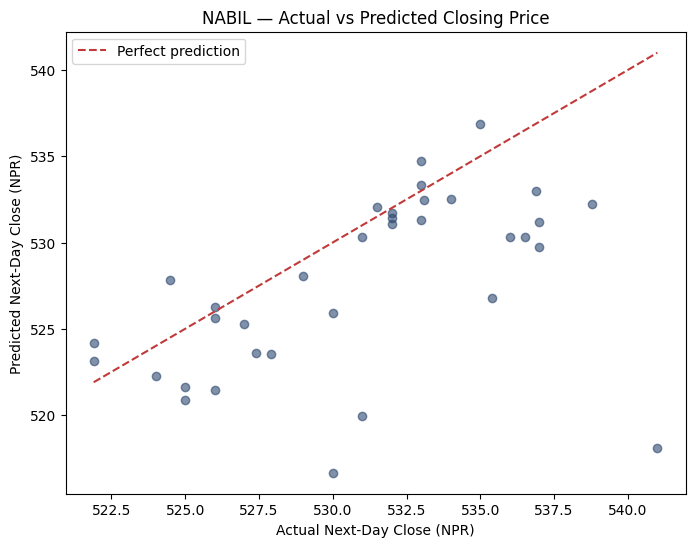

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="#2C4870")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="#C13A3A", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Next-Day Close (NPR)")
plt.ylabel("Predicted Next-Day Close (NPR)")
plt.title("NABIL — Actual vs Predicted Closing Price")
plt.legend()
plt.show()


In [ ]:
latest = data[features].iloc[[-1]]
latest_scaled = scaler.transform(latest)

predicted_price = lr_model.predict(latest_scaled)

last_date = data["Date"].iloc[-1]
predicted_date = last_date + pd.Timedelta(days=1)

print(f"Prediction Date: {predicted_date.strftime('%Y-%m-%d')}")
print(f"Predicted Closing Price: {predicted_price[0]:.2f} NPR")